# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Custom Text Corpus
This project uses a custom paragraph corpus, cleaned before tokenization. The corpus is intentionally small for beginner-level training, but the same pipeline works for larger text files.

In [2]:
# Custom paragraph corpus for the student task
corpus = """
Artificial intelligence is changing the way students learn and solve problems.
Deep learning models observe patterns in data and improve through repeated training.
Recurrent neural networks read text step by step and remember previous words.
LSTM networks use gates to store important context for a longer time.
GRU networks are simpler gated models that train quickly and perform well.
Text generation systems predict the next word from the words that came before it.
A good language model learns grammar, meaning, and sentence structure from examples.
When the model receives a seed phrase, it continues the sentence using learned patterns.
"""

# Basic cleaning: lowercase text and remove extra spaces/new lines
corpus = corpus.lower().strip()
corpus = "\n".join(line.strip() for line in corpus.split("\n") if line.strip())

print(corpus)

artificial intelligence is changing the way students learn and solve problems.
deep learning models observe patterns in data and improve through repeated training.
recurrent neural networks read text step by step and remember previous words.
lstm networks use gates to store important context for a longer time.
gru networks are simpler gated models that train quickly and perform well.
text generation systems predict the next word from the words that came before it.
a good language model learns grammar, meaning, and sentence structure from examples.
when the model receives a seed phrase, it continues the sentence using learned patterns.


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

# Progressive sliding-window / n-gram sequences
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

# Match vector dimensions using pad_sequences
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Maximum sequence length:", max_len)
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 78
Maximum sequence length: 14
X shape: (91, 13)
y shape: (91,)


In [4]:
# Shared configuration for all three models
# Student customizations included:
# 1. Custom corpus above
# 2. Embedding dimension increased from 32 to 64
# 3. Epochs increased from 100 to 200
# 4. Hidden units increased from 64 to 128
# 5. Text generation output changed from 5 to 10 words

EMBEDDING_DIM = 64
HIDDEN_UNITS = 128
EPOCHS = 200
OPTIMIZER_CONFIG = Adam(learning_rate=0.001)

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer=Adam(learning_rate=0.001),
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

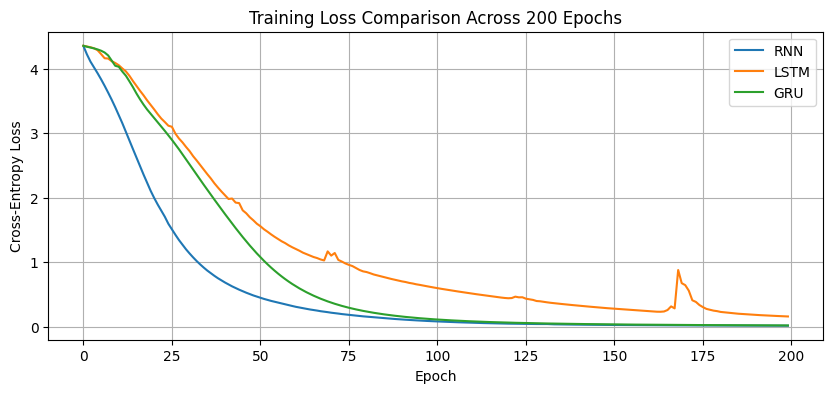

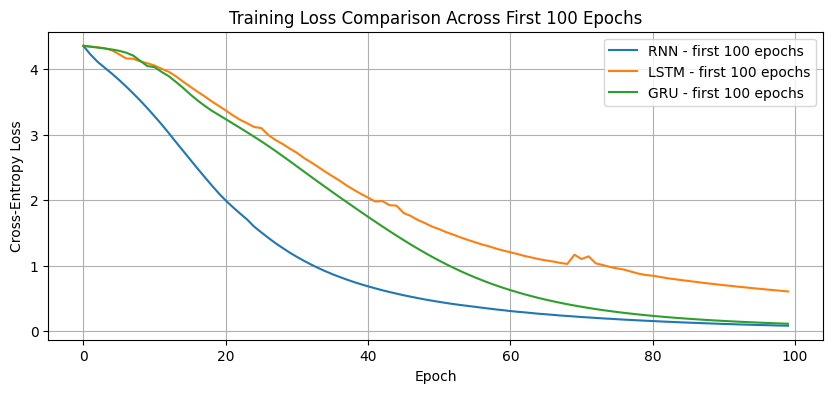

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Comparison Across 200 Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Evaluator requirement: complete cross-entropy loss curve across the first 100 epochs
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'][:100], label='RNN - first 100 epochs')
plt.plot(lstm_history.history['loss'][:100], label='LSTM - first 100 epochs')
plt.plot(gru_history.history['loss'][:100], label='GRU - first 100 epochs')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Comparison Across First 100 Epochs")
plt.legend()
plt.grid(True)
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=10):
    """Generate text using greedy decoding with np.argmax."""
    seed_text = seed_text.lower().strip()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')

        # Internal selection logic: choose word with highest predicted probability
        next_word_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(next_word_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        if output_word == "":
            break

        seed_text += " " + output_word

    return seed_text

## 🧪 Generate Text Samples

In [10]:
seed_phrase = "deep learning"

print("Seed phrase:", seed_phrase)
print("RNN :", generate_text(rnn_model, seed_phrase, next_words=10))
print("LSTM:", generate_text(lstm_model, seed_phrase, next_words=10))
print("GRU :", generate_text(gru_model, seed_phrase, next_words=10))

Seed phrase: deep learning
RNN : deep learning models observe patterns in data and improve through repeated training
LSTM: deep learning models observe patterns in data and improve through repeated training
GRU : deep learning models observe patterns in data and improve through repeated training


# 📚 Student Learning Tasks Completed
### ✅ Beginner Customizations Implemented
1. Boilerplate corpus replaced with a custom paragraph corpus.
2. Embedding dimension increased from 32 to 64.
3. Training expanded from 100 epochs to 200 epochs.
4. Hidden layers widened from 64 units to 128 units.
5. Text generation now returns 10 words per seed prompt.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**